# nnlab Getting Started

This notebook introduces the basic building blocks of nnlab.

We will construct a small neural network pipeline manually:

1. Define a transition kernel
2. Build a parameterized activation function
3. Create a dense layer
4. Apply the activation through an activation layer
5. Generate predictions
6. Measure error using a loss function
7. Visualize the behavior

The goal is not training yet, but understanding how the
components interact.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nnlab.kernels import LogisticKernel

from nnlab.activations import ParameterizedActivation

from nnlab.layers import ( Dense, ActivationLayer )

from nnlab.models import FeedForward

from nnlab.losses import MeanSquaredError 

from nnlab.visualization import plot_activation 

## Step 1: Transition Kernel

The transition kernel defines the mathematical shape of the
activation transformation.

Here we use a logistic transition:

$$
K(x)=\frac{1}{1+e^{-x}}
$$

The kernel itself does not know about neural networks.
It only defines a mathematical response curve.

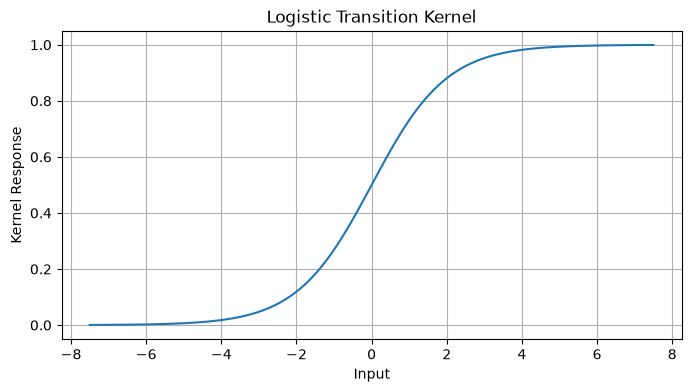

In [2]:
kernel = LogisticKernel()

x = np.linspace( -7.5, 7.5, 500 )
y = kernel.forward(x)

plt.figure(figsize=(8,4))

plt.plot( x,  y )
plt.title( "Logistic Transition Kernel" )
plt.xlabel( "Input" )
plt.ylabel( "Kernel Response" )
plt.grid(True)

plt.show()

## Step 2: Parameterized Activation

The activation wraps the kernel and introduces parameters:

$$
\phi(x)=aK(\frac{x-c}{w})+b
$$

where:

- $c$ controls center
- $w$ controls width
- $a$ controls scale
- $b$ controls offset

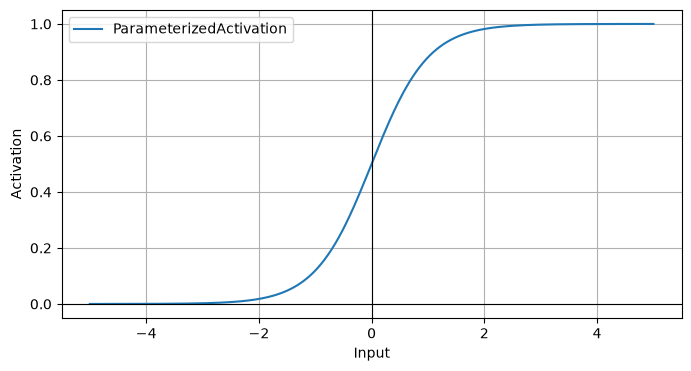

In [4]:
activation = ParameterizedActivation(
    kernel=kernel,
    center=0.0,
    kernel_scale=0.50,
    amplitude=1.0,
    bias=0.0,
)

plot_activation( activation )

## Step 3: Dense Layer

A dense layer performs:

$$
y = Wx+b
$$

The layer performs a linear projection.
The activation function will introduce non-linearity.

In [5]:
dense = Dense(
    input_size=1,
    output_size=1,
)

dense.weights = np.array( [ [2.0] ] )
dense.bias = np.array( [ 0.5 ] )

activation_layer = ActivationLayer(
    activation=activation,
)

## Step 4: Compose Layers

A neural network is a composition of transformations.

Our network:

$$
x
\rightarrow Wx+b
\rightarrow \phi(x)
$$

In [6]:
model = FeedForward( layers=[ dense, activation_layer, ] )

x = np.linspace( -3, 3, 200 ).reshape( -1, 1 )

prediction = model.forward( x )
prediction.shape

(200, 1)

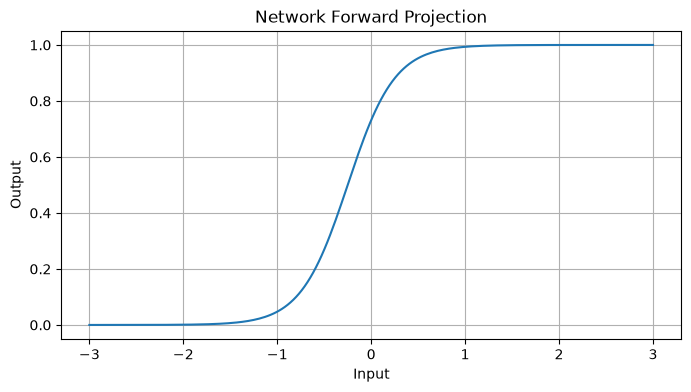

In [7]:
plt.figure(figsize=(8,4))

plt.plot( x, prediction )

plt.title( "Network Forward Projection" )
plt.xlabel( "Input" )
plt.ylabel( "Output" )
plt.grid(True)

plt.show()

## Step 5: Evaluate Error

A loss function measures the difference between
the network output and the desired target.

Here we create a simple target function:

$$
y=x^2
$$

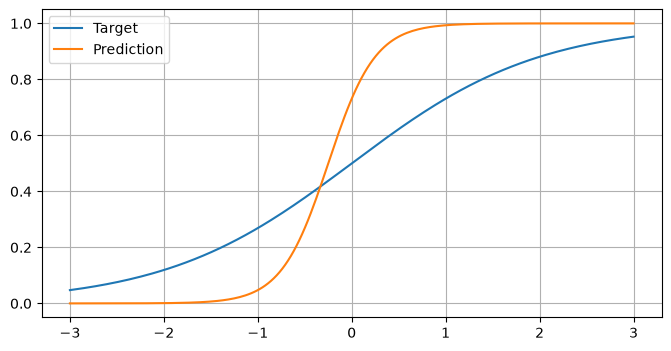

In [8]:
# target = x**2
target = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8,4))

plt.plot(
    x,
    target,
    label="Target",
)

plt.plot(
    x,
    prediction,
    label="Prediction",
)

plt.legend()

plt.grid(True)

plt.show()



In [9]:
loss = MeanSquaredError()

error = loss.forward(
    prediction,
    target,
)

error

0.03294585521358889

The network has not been trained.

The purpose of this example is only to demonstrate:

input
→ dense transformation
→ activation
→ prediction
→ loss measurement

Training will be introduced in later experiments.